In [ ]:
import pandas as mypd

In [ ]:
# Install required libraries
!pip install --upgrade gspread gspread_dataframe


In [ ]:
# Import necessary libraries
import gspread
from google.colab import auth
from google.auth import default
from gspread_dataframe import get_as_dataframe

In [ ]:
# Authenticate and connect to Google Sheets
auth.authenticate_user()
creds, _ = default()
gc = gspread.authorize(creds)

In [ ]:
# Open the Google Sheet (Replace with your sheet name or URL)
spreadsheet_url = "https://docs.google.com/spreadsheets/d/1Z7sbatVkHYxGNUxZYvG6Bv-eOrpBNRngu9vetLOm0v4/edit?gid=313492299#gid=313492299"
sh = gc.open_by_url(spreadsheet_url)

# Select a worksheet (default is the first sheet)
worksheet = sh.worksheet('Productivity')  # You can also use `sh.worksheet('Sheet_Name')`

# Read data into a Pandas DataFrame
mydata = get_as_dataframe(worksheet, evaluate_formulas=True)

In [ ]:
#Check first few colomn of Data
mydata.tail() #for last check last 06 rows

,Developer_Experience,Code_Reuse,Knowledge_Repository_Usage,Productivity
25,1.0,1.0,1.0,130.0
26,2.0,1.0,1.0,75.0
27,2.0,2.0,2.0,20.0
28,1.0,1.0,2.0,40.0
29,1.0,1.0,2.0,60.0


In [ ]:
#Basic Information about data
mydata.info()

<class 'pandas.core.frame.DataFrame'>
Index: 30 entries, 0 to 29
Data columns (total 4 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Developer_Experience        30 non-null     float64
 1   Code_Reuse                  30 non-null     float64
 2   Knowledge_Repository_Usage  30 non-null     float64
 3   Productivity                30 non-null     float64
dtypes: float64(4)
memory usage: 1.2 KB


In [ ]:
mydata.describe()

,Developer_Experience,Code_Reuse,Knowledge_Repository_Usage,Productivity
count,30.000000,30.000000,30.000000,30.000000
mean,1.500000,1.466667,1.700000,80.833333
std,0.508548,0.507416,0.466092,52.227674
min,1.000000,1.000000,1.000000,20.000000
25%,1.000000,1.000000,1.000000,40.000000
50%,1.500000,1.000000,2.000000,60.000000
75%,2.000000,2.000000,2.000000,122.500000
max,2.000000,2.000000,2.000000,200.000000


In [ ]:
#Compute descriptive summary of variable Productivity
mydata.Productivity.describe()

,Productivity
count,30.000000
mean,80.833333
std,52.227674
min,20.000000
25%,40.000000
50%,60.000000
75%,122.500000
max,200.000000


In [ ]:
print("Median of prodectivity",mydata.Productivity.median())
print("Mean of prodectivity",round(mydata.Productivity.mean(),2))


Median of prodectivity 60.0
Mean of prodectivity 80.83


In [ ]:
#Plot the graphs
#import package
import matplotlib.pyplot as plt
import seaborn as sns

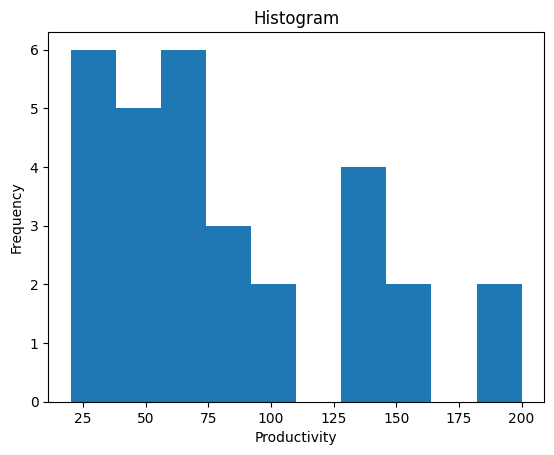

In [ ]:
# Plot Histogram
plt.hist(mydata.Productivity)
plt.title("Histogram")
plt.xlabel("Productivity")
plt.ylabel("Frequency")
plt.show()


In [ ]:
import numpy as np
# Select a numeric column to visualize (replace 'column_name' with an actual column name)
column_name = "Productivity"
data=mydata[column_name]
# Compute Quartiles and IQR
Q1 = np.percentile(data, 25)
Q2 = np.percentile(data, 50)  # Median
Q3 = np.percentile(data, 75)
IQR = Q3 - Q1  # Interquartile Range

# Define Outlier Thresholds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identify Outliers
outliers = data[(data < lower_bound) | (data > upper_bound)]

# Print Quartiles and Outliers
print(f"Q1 (25th percentile): {Q1}")
print(f"Q2 (Median - 50th percentile): {Q2}")
print(f"Q3 (75th percentile): {Q3}")
print(f"IQR (Interquartile Range): {IQR}")
print(f"Lower Bound: {lower_bound}")
print(f"Upper Bound: {upper_bound}")
print("\nOutliers:")
print(outliers.to_list())  # Print outlier values as a list

Q1 (25th percentile): 40.0
Q2 (Median - 50th percentile): 60.0
Q3 (75th percentile): 122.5
IQR (Interquartile Range): 82.5
Lower Bound: -83.75
Upper Bound: 246.25

Outliers:
[]


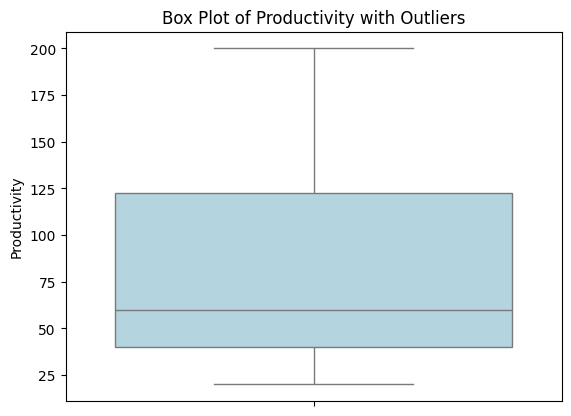

In [ ]:
#create Box Plot
# Plot Box Plot with Outliers Highlighted
#plt.figure(figsize=(8, 5))
sns.boxplot(y=data, color="lightblue")

# Highlight Outliers in Red
for outlier in outliers:
    plt.scatter(1, outlier, color="red", s=100, label="Outlier")

plt.title(f"Box Plot of {column_name} with Outliers")
plt.ylabel(column_name)
plt.show()

<Axes: xlabel='Developer_Experience', ylabel='Productivity'>

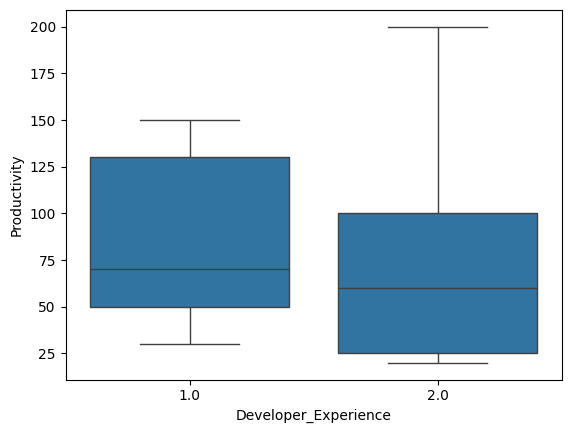

In [ ]:
#Check whether the Productivity varies with developer experience?
sns.boxplot(x = 'Developer_Experience', y = 'Productivity', data = mydata)

<Axes: xlabel='Knowledge_Repository_Usage', ylabel='Productivity'>

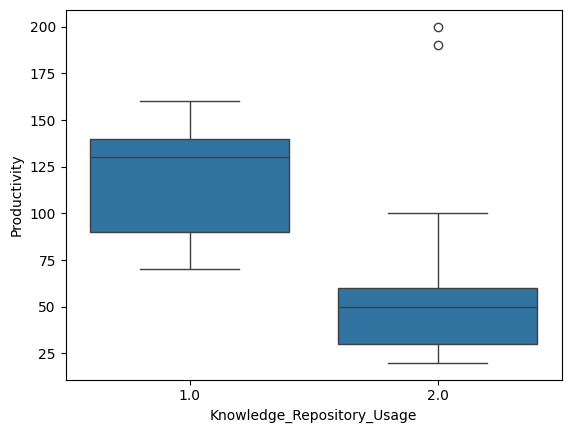

In [ ]:
#Check whether the average productivity varies with knowledge repository usage?
sns.boxplot(x = 'Knowledge_Repository_Usage', y = 'Productivity', data = mydata)

<Axes: xlabel='Code_Reuse', ylabel='Productivity'>

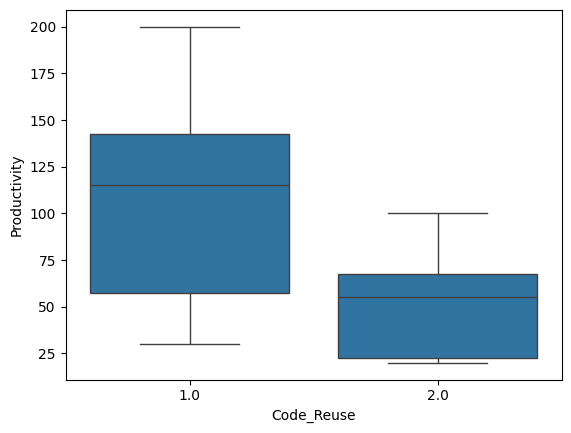

In [ ]:
#Check whether the average productivity varies with Code reuse?
sns.boxplot(x = 'Code_Reuse', y = 'Productivity', data = mydata)

Knowledge_Repository_Usage  Productivity
Developer_Experience Code_Reuse                                          
1.0                  1.0                           1.500000     91.000000
                     2.0                           1.600000     72.000000
2.0                  1.0                           1.666667    130.833333
                     2.0                           2.000000     41.111111

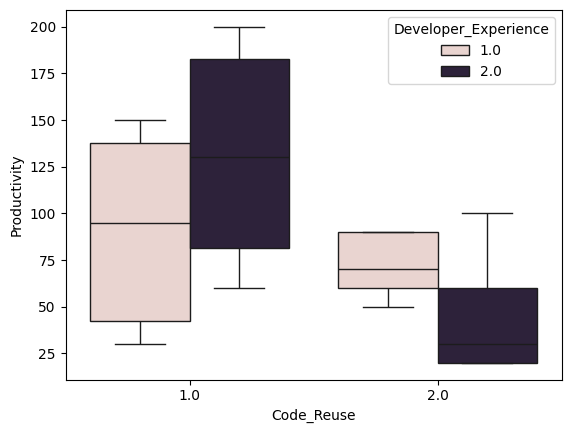

In [ ]:
#Compute the aggregate average of productivity with developer experience & code reuse?
sns.boxplot(x="Code_Reuse", y="Productivity",hue="Developer_Experience",data=mydata)
mydata.groupby(['Developer_Experience','Code_Reuse']).mean()

<Figure size 1200x800 with 0 Axes>

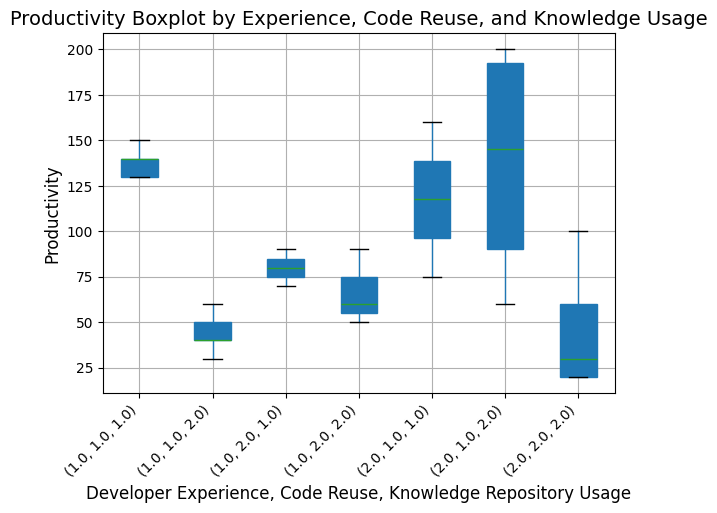

Productivity
Developer_Experience Code_Reuse Knowledge_Repository_Usage              
1.0                  1.0        1.0                           138.000000
                                2.0                            44.000000
                     2.0        1.0                            80.000000
                                2.0                            66.666667
2.0                  1.0        1.0                           117.500000
                                2.0                           137.500000
                     2.0        2.0                            41.111111

In [ ]:
#Compute the aggregate average of usage with all three factors?
# Create the boxplot
plt.figure(figsize=(12, 8))
boxplot = mydata.boxplot(column='Productivity',
                         by=['Developer_Experience', 'Code_Reuse', 'Knowledge_Repository_Usage'],
                         patch_artist=True)

# Improve layout
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for better readability
plt.xlabel("Developer Experience, Code Reuse, Knowledge Repository Usage", fontsize=12)
plt.ylabel("Productivity", fontsize=12)
plt.title("Productivity Boxplot by Experience, Code Reuse, and Knowledge Usage", fontsize=14)
plt.suptitle("")  # Remove automatic subtitle

plt.show()
mydata.groupby(['Developer_Experience','Code_Reuse','Knowledge_Repository_Usage']).mean()